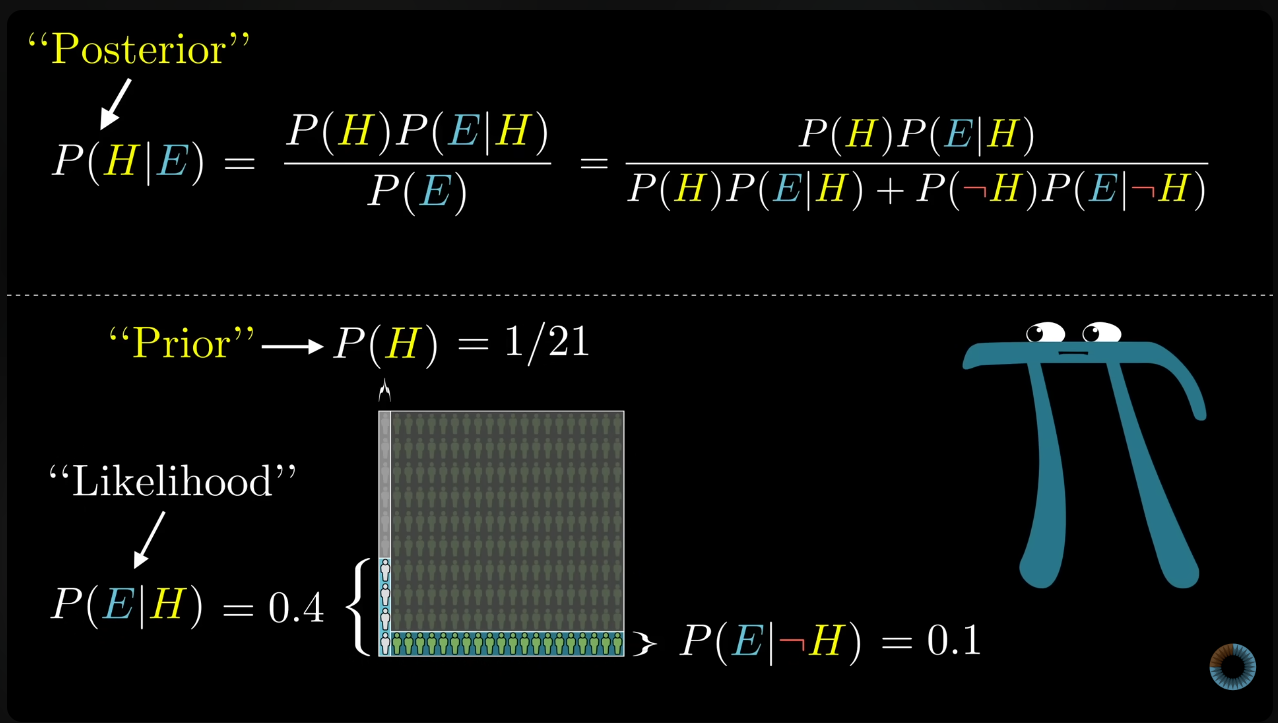

In [2]:
import pandas as pd
df = pd.read_csv("D:/Learn_ML/ML_algos/datasets/spam.csv" , encoding = "latin-1")
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [4]:
df = df.drop(columns=['Unnamed: 2' , 'Unnamed: 3' , 'Unnamed: 4'])

In [5]:
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [6]:
df = df[['v1', 'v2']]
df.columns = ['label', 'message']
df['label'] = df['label'].map({'ham': 0, 'spam': 1})
df.head()


,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [7]:
df['label'].value_counts()


label
0    4825
1     747
Name: count, dtype: int64

In [15]:
import re
def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]' , '' , text)
    words = text.split()
    return words


In [16]:
df['tokens'] = df['message'].apply(preprocess)

In [17]:
df.head()

,label,message,tokens
0,0,"Go until jurong point, crazy.. Available only ...","[go, until, jurong, point, crazy, available, o..."
1,0,Ok lar... Joking wif u oni...,"[ok, lar, joking, wif, u, oni]"
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,"[free, entry, in, a, wkly, comp, to, win, fa, ..."
3,0,U dun say so early hor... U c already then say...,"[u, dun, say, so, early, hor, u, c, already, t..."
4,0,"Nah I don't think he goes to usf, he lives aro...","[nah, i, dont, think, he, goes, to, usf, he, l..."


My understanding of naive bayes:
we need p(spam) and p(ham) which we can calculate from number of spams/total number of emails same for ham , and after that we need probability of each word given its spam (we have to do this for entire vocab) and we need probability of each word given its notspam (we have to do this for entire vocab) if we figure this out your training is done , after that all we have to do is tokenise the test text and multiply the probabilities of the words(which we have calculated earlier) do this for spam as well as not spam , and take whichb ever has highest probabilty this is the traditional naive bayes

tldr : 
We need

• P(spam) and P(ham)

• P(word | spam) for all words

• P(word | ham) for all words


After that training is done

Then for a test message we tokenize and multiply probabilities and pick the bigger one

notes_link : https://www.notion.so/Naive-Bayes-Notes-300c72f463d880939599ee60807e01d0?source=copy_link

In [24]:
vocab = set()
for words in df['tokens']:
    for word in words:
        vocab.add(word)
print(len(vocab))

8538


Computing probablities p(spam) , p(ham)

In [25]:
total_rows = len(df)
count_spam = (df['label'] == 1).sum()
p_spam = count_spam / total_rows


count_ham = (df['label'] == 0).sum()
p_ham = count_ham / total_rows

print(p_spam ,  p_ham)

0.13406317300789664 0.8659368269921034


Computing probabilites for p(w | ham) and p(w | spam) and storing them in a dictionary

In [26]:
spam_tokens = df[df['label'] == 1]['tokens']
ham_tokens = df[df['label'] == 0]['tokens']
print(spam_tokens)
print(ham_tokens)

2       [free, entry, in, a, wkly, comp, to, win, fa, ...
5       [freemsg, hey, there, darling, its, been, week...
8       [winner, as, a, valued, network, customer, you...
9       [had, your, mobile, months, or, more, u, r, en...
11      [six, chances, to, win, cash, from, to, pounds...
                              ...                        
5537    [want, explicit, sex, in, secs, ring, now, cos...
5540    [asked, mobile, if, chatlines, inclu, in, free...
5547    [had, your, contract, mobile, mnths, latest, m...
5566    [reminder, from, o, to, get, pounds, free, cal...
5567    [this, is, the, nd, time, we, have, tried, con...
Name: tokens, Length: 747, dtype: object
0       [go, until, jurong, point, crazy, available, o...
1                          [ok, lar, joking, wif, u, oni]
3       [u, dun, say, so, early, hor, u, c, already, t...
4       [nah, i, dont, think, he, goes, to, usf, he, l...
6       [even, my, brother, is, not, like, to, speak, ...
                              .

In [27]:
from collections import defaultdict
spam_words_freq = defaultdict(int)
ham_words_freq = defaultdict(int)
for tokens in spam_tokens:
    for word in tokens:
        spam_words_freq[word] += 1
for tokens in ham_tokens:
    for word in tokens:
        ham_words_freq[word] += 1

In [29]:
print(spam_words_freq)
print(ham_words_freq)

defaultdict(<class 'int'>, {'free': 219, 'entry': 26, 'in': 74, 'a': 378, 'wkly': 14, 'comp': 10, 'to': 686, 'win': 61, 'fa': 4, 'cup': 5, 'final': 16, 'tkts': 4, 'st': 30, 'may': 7, 'text': 121, 'receive': 33, 'questionstd': 2, 'txt': 151, 'ratetcs': 2, 'apply': 30, 'overs': 2, 'freemsg': 12, 'hey': 5, 'there': 11, 'darling': 2, 'its': 12, 'been': 43, 'weeks': 13, 'now': 190, 'and': 122, 'no': 77, 'word': 22, 'back': 23, 'id': 3, 'like': 13, 'some': 6, 'fun': 9, 'you': 287, 'up': 21, 'for': 204, 'it': 28, 'still': 7, 'tb': 1, 'ok': 5, 'xxx': 12, 'std': 9, 'chgs': 1, 'send': 67, 'rcv': 4, 'winner': 16, 'as': 33, 'valued': 11, 'network': 25, 'customer': 49, 'have': 135, 'selected': 25, 'receivea': 2, 'prize': 92, 'reward': 10, 'claim': 113, 'call': 350, 'code': 29, 'kl': 2, 'valid': 23, 'hours': 6, 'only': 84, 'had': 18, 'your': 263, 'mobile': 124, 'months': 6, 'or': 188, 'more': 30, 'u': 155, 'r': 23, 'entitled': 8, 'update': 19, 'the': 204, 'latest': 36, 'colour': 17, 'mobiles': 12, '

In [32]:
total_spam_words = sum(spam_words_freq.values())
total_ham_words = sum(ham_words_freq.values())

prob_dictionary contains  p(w | spam) and p(w | ham) as values , with words in vocab as key
Laplace smoothing along with no log transformation

In [42]:
prob_dictionary = {}
V = len(vocab)

for word in vocab:
    p_w_given_spam = (spam_words_freq[word] + 1) / (total_spam_words + V)
    p_w_given_ham  = (ham_words_freq[word] + 1) / (total_ham_words + V)

    prob_dictionary[word] = {
        "spam": p_w_given_spam,
        "ham":  p_w_given_ham
    }


In [43]:
print(prob_dictionary)

{'few': {'spam': 4.107788366743346e-05, 'ham': 0.0005995123965841115}, 'question': {'spam': 0.00020538941833716726, 'ham': 0.00021315996322990636}, 'credits': {'spam': 0.0004107788366743345, 'ham': 1.3322497701869147e-05}, 'blank': {'spam': 4.107788366743346e-05, 'ham': 6.661248850934573e-05}, 'vldo': {'spam': 4.107788366743346e-05, 'ham': 2.6644995403738294e-05}, 'inpersonation': {'spam': 4.107788366743346e-05, 'ham': 2.6644995403738294e-05}, 'it': {'spam': 0.0011912586263555702, 'ham': 0.007873596141804665}, 'swalpa': {'spam': 4.107788366743346e-05, 'ham': 2.6644995403738294e-05}, 'heehee': {'spam': 4.107788366743346e-05, 'ham': 2.6644995403738294e-05}, 'cup': {'spam': 0.00024646730200460074, 'ham': 6.661248850934573e-05}, 'tfp': {'spam': 8.215576733486691e-05, 'ham': 1.3322497701869147e-05}, 'difficulties': {'spam': 4.107788366743346e-05, 'ham': 3.996749310560744e-05}, 'bcm': {'spam': 0.00016431153466973383, 'ham': 1.3322497701869147e-05}, 'yummy': {'spam': 4.107788366743346e-05, 'h

In [44]:
def predict_no_log(message):
    words = preprocess(message)

    spam_score = p_spam
    ham_score  = p_ham

    for word in words:
        if word in prob_dictionary:
            spam_score *= prob_dictionary[word]["spam"]
            ham_score  *= prob_dictionary[word]["ham"]

    return spam_score, ham_score


In [45]:
msg = "free win"
spam_score, ham_score = predict_no_log(msg)

print("Spam score:", spam_score)
print("Ham score :", ham_score)
print("Prediction:", "SPAM" if spam_score > ham_score else "HAM")


Spam score: 3.0856025565112315e-06
Ham score : 1.1065983398899074e-07
Prediction: SPAM


In [47]:
msg = "free win prize claim now urgent offer"
spam_score, ham_score = predict_no_log(msg)

print("Prediction:", "SPAM" if spam_score > ham_score else "HAM")


Prediction: SPAM
